# 국가별 경제 성장(GDP)과 이산화탄소(CO₂) 배출량의 상관관계 분석

본 프로젝트는 국가별 GDP와 CO₂ 배출량 간의 관계를 시각화 중심으로 탐색한 분석이다.  
총량, 1인당 지표, 성장률, 대표 국가 사례, 그리고 국가 특성별 카테고리 분석을 통해  
경제 성장과 탄소 배출 간의 동조화 및 탈동조화 양상을 구조적으로 살펴본다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform

sns.set_theme(style="whitegrid")
plt.rcParams["axes.unicode_minus"] = False

if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

In [2]:
df = pd.read_csv("gdp_co2_by_country_v2.csv")

print("원본 데이터 크기:", df.shape)
print("컬럼 수:", len(df.columns))
df.head()

원본 데이터 크기: (12444, 21)
컬럼 수: 21


,Country Name,Country Code,Year,Population,Pop Log,Pop Outliers,Pop Category,CO2,CO2 %,Cumulative CO2,...,CO2 Outliers,Emissions Category,GDP USD,GDP USD Log,GDP %,GDP % Winsor,GDP Per Capita,GDP Category,CO2 Per GDP,Per Capita CO2 (kg)
0,Afghanistan,AFG,1961,9214082.0,16.036244,not outlier,1M-10M,0.491,NaN,235.001,...,False,Moderate,308.31827,5.734371,-10.119484,-10.119484,0.000033,Low GDP,0.001593,0.000053
1,Afghanistan,AFG,1962,9404411.0,16.056689,not outlier,1M-10M,0.689,40.325866,235.001,...,False,Moderate,308.31827,5.734371,-10.119484,-10.119484,0.000033,Low GDP,0.002235,0.000073
2,Afghanistan,AFG,1963,9604491.0,16.077741,not outlier,1M-10M,0.707,2.612482,235.001,...,False,Moderate,308.31827,5.734371,-10.119484,-10.119484,0.000032,Low GDP,0.002293,0.000074
3,Afghanistan,AFG,1964,9814318.0,16.099353,not outlier,1M-10M,0.839,18.670438,235.001,...,False,Moderate,308.31827,5.734371,-10.119484,-10.119484,0.000031,Low GDP,0.002721,0.000085
4,Afghanistan,AFG,1965,10036003.0,16.121690,not outlier,10M-100M,1.007,20.023838,235.001,...,False,Moderate,308.31827,5.734371,-10.119484,-10.119484,0.000031,Low GDP,0.003266,0.000100


In [3]:
df = df.replace([np.inf, -np.inf], np.nan)

df_cleaned = df.dropna(subset=["CO2 %", "GDP %"]).copy()

print("전처리 후 데이터 크기:", df_cleaned.shape)
print(df_cleaned[["CO2 %", "GDP %"]].isna().sum())

전처리 후 데이터 크기: (12237, 21)
CO2 %    0
GDP %    0
dtype: int64


In [4]:
columns_to_keep_for_full_analysis = [
    "Country Name", "Country Code", "Year",
    "Population", "Pop Category",
    "CO2", "CO2 %", "Per Capita CO2 (kg)", "CO2 Log", "Emissions Category",
    "GDP USD", "GDP %", "GDP Per Capita", "GDP USD Log", "GDP Category"
]

missing_cols = set(columns_to_keep_for_full_analysis) - set(df_cleaned.columns)
assert not missing_cols, f"Missing columns: {missing_cols}"

df_full_analysis = df_cleaned[columns_to_keep_for_full_analysis].copy()

print("분석용 데이터 크기:", df_full_analysis.shape)
df_full_analysis.head()

분석용 데이터 크기: (12237, 15)


,Country Name,Country Code,Year,Population,Pop Category,CO2,CO2 %,Per Capita CO2 (kg),CO2 Log,Emissions Category,GDP USD,GDP %,GDP Per Capita,GDP USD Log,GDP Category
1,Afghanistan,AFG,1962,9404411.0,1M-10M,0.689,40.325866,0.000073,0.524137,Moderate,308.31827,-10.119484,0.000033,5.734371,Low GDP
2,Afghanistan,AFG,1963,9604491.0,1M-10M,0.707,2.612482,0.000074,0.534737,Moderate,308.31827,-10.119484,0.000032,5.734371,Low GDP
3,Afghanistan,AFG,1964,9814318.0,1M-10M,0.839,18.670438,0.000085,0.609222,Moderate,308.31827,-10.119484,0.000031,5.734371,Low GDP
4,Afghanistan,AFG,1965,10036003.0,10M-100M,1.007,20.023838,0.000100,0.696641,Moderate,308.31827,-10.119484,0.000031,5.734371,Low GDP
5,Afghanistan,AFG,1966,10266397.0,10M-100M,1.091,8.341609,0.000106,0.737642,Moderate,308.31827,-10.119484,0.000030,5.734371,Low GDP


In [5]:
# 총량 기준 상관관계
gdp_co2_correlation_by_country = (
    df_full_analysis.groupby("Country Name")[["GDP USD", "CO2"]]
    .corr()
    .unstack()
    .loc[:, ("GDP USD", "CO2")]
)
gdp_co2_correlation_by_country.name = "GDP_CO2_Correlation"

# 1인당 기준 상관관계
gdp_per_capita_co2_per_capita_correlation_by_country = (
    df_full_analysis.groupby("Country Name")[["GDP Per Capita", "Per Capita CO2 (kg)"]]
    .corr()
    .unstack()
    .loc[:, ("GDP Per Capita", "Per Capita CO2 (kg)")]
)
gdp_per_capita_co2_per_capita_correlation_by_country.name = "GDP_Per_Capita_CO2_Per_Capita_Correlation"

# 국가별 카테고리 정보
country_categories = (
    df_full_analysis.groupby("Country Name")[["Pop Category", "Emissions Category", "GDP Category"]]
    .agg(lambda x: x.dropna().mode().iloc[0] if len(x.dropna()) > 0 else np.nan)
)

# 국가별 관측치 수
n_obs = df_full_analysis.groupby("Country Name").size().rename("n_years")

# 최종 상관관계 테이블
correlations_df = pd.concat(
    [
        gdp_co2_correlation_by_country,
        gdp_per_capita_co2_per_capita_correlation_by_country,
        country_categories,
        n_obs
    ],
    axis=1
).reset_index()

print("국가 수:", correlations_df.shape[0])
correlations_df.head()

국가 수: 203


,Country Name,GDP_CO2_Correlation,GDP_Per_Capita_CO2_Per_Capita_Correlation,Pop Category,Emissions Category,GDP Category,n_years
0,Afghanistan,0.878499,-0.139085,10M-100M,Moderate,Low GDP,62
1,Albania,0.145799,0.092586,1M-10M,Moderate,Middle GDP,62
2,Algeria,0.877462,-0.594108,10M-100M,Very High,Middle GDP,62
3,Andorra,0.563584,0.475197,<1M,Low,High GDP,33
4,Angola,0.083303,-0.650092,10M-100M,High,Middle GDP,62


In [6]:
min_years = 10

valid_countries = (
    correlations_df.loc[correlations_df["n_years"] >= min_years, "Country Name"]
)

corr_plot_df = correlations_df[
    correlations_df["Country Name"].isin(valid_countries)
].copy()

print(f"{min_years}년 이상 관측된 국가 수:", corr_plot_df.shape[0])

10년 이상 관측된 국가 수: 203


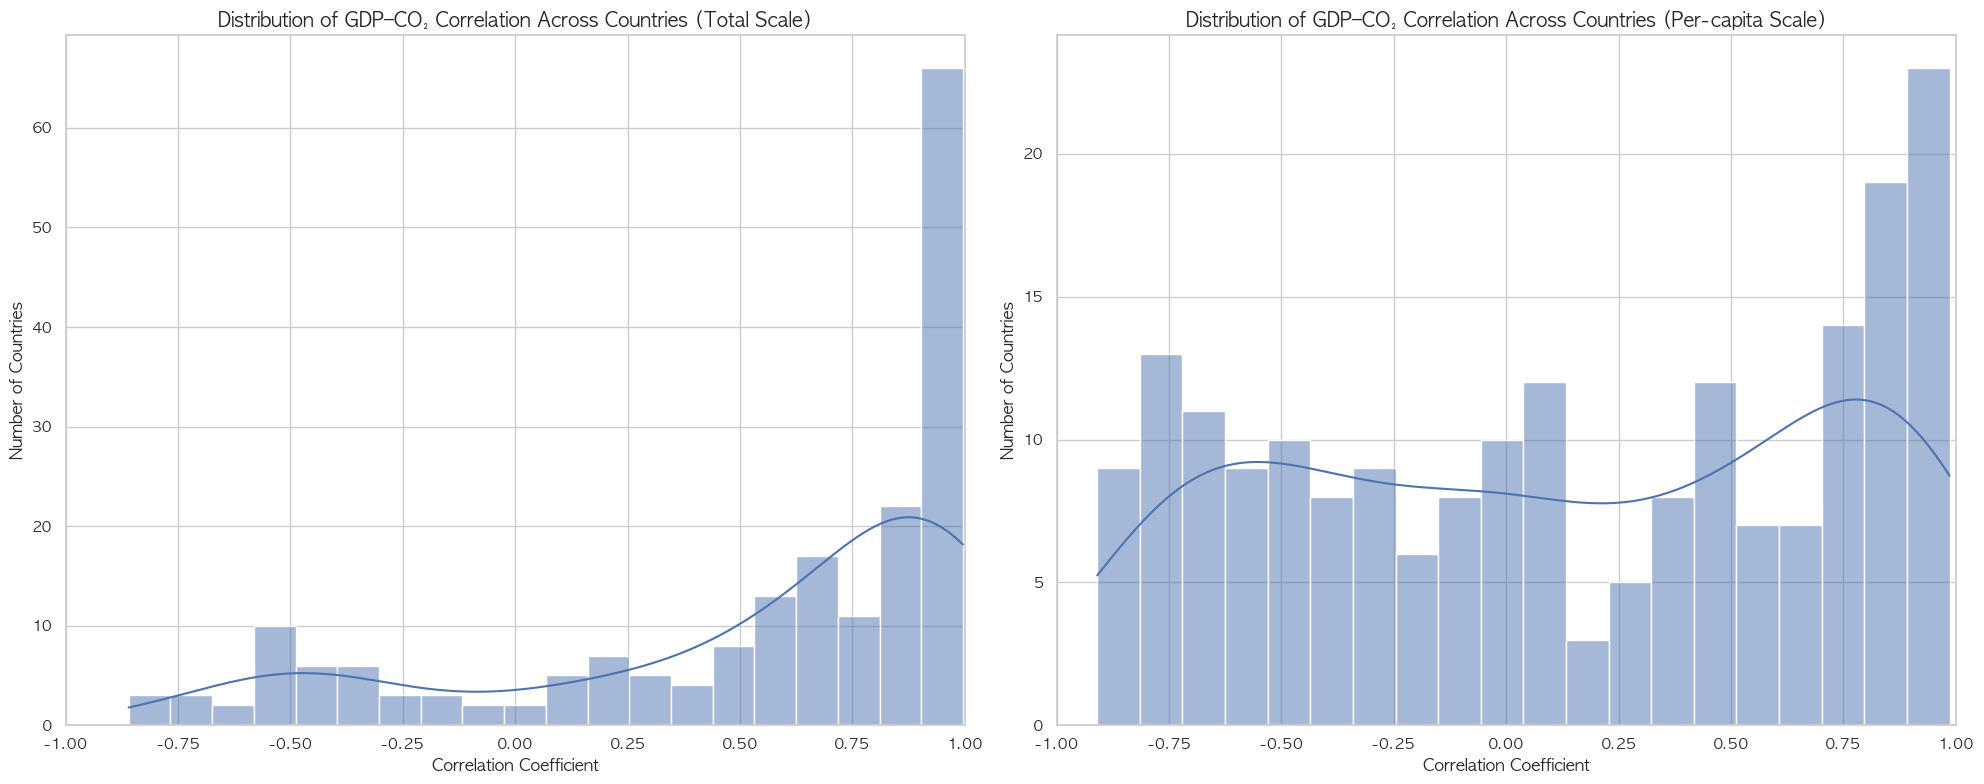

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# 총량 기준
sns.histplot(
    corr_plot_df["GDP_CO2_Correlation"],
    kde=True,
    bins=20,
    ax=axes[0]
)
axes[0].set_title("Distribution of GDP–CO₂ Correlation Across Countries (Total Scale)", fontsize=14)
axes[0].set_xlabel("Correlation Coefficient")
axes[0].set_ylabel("Number of Countries")
axes[0].set_xlim(-1, 1)

# 1인당 기준
sns.histplot(
    corr_plot_df["GDP_Per_Capita_CO2_Per_Capita_Correlation"],
    kde=True,
    bins=20,
    ax=axes[1]
)
axes[1].set_title("Distribution of GDP–CO₂ Correlation Across Countries (Per-capita Scale)", fontsize=14)
axes[1].set_xlabel("Correlation Coefficient")
axes[1].set_ylabel("Number of Countries")
axes[1].set_xlim(-1, 1)

plt.tight_layout()
plt.show()

**해석**  
대부분의 국가에서는 총 GDP와 CO₂ 배출량 간에 강한 양(+)의 상관관계가 나타난다.  
반면, 1인당 GDP와 1인당 CO₂ 배출량 간의 상관관계는 분산이 크며,  
일부 국가에서는 음(–)의 상관관계가 관찰되어 경제 성장과 탄소 배출 간의 탈동조화 가능성을 시사한다.

Growth-rate plot sample size: 12237


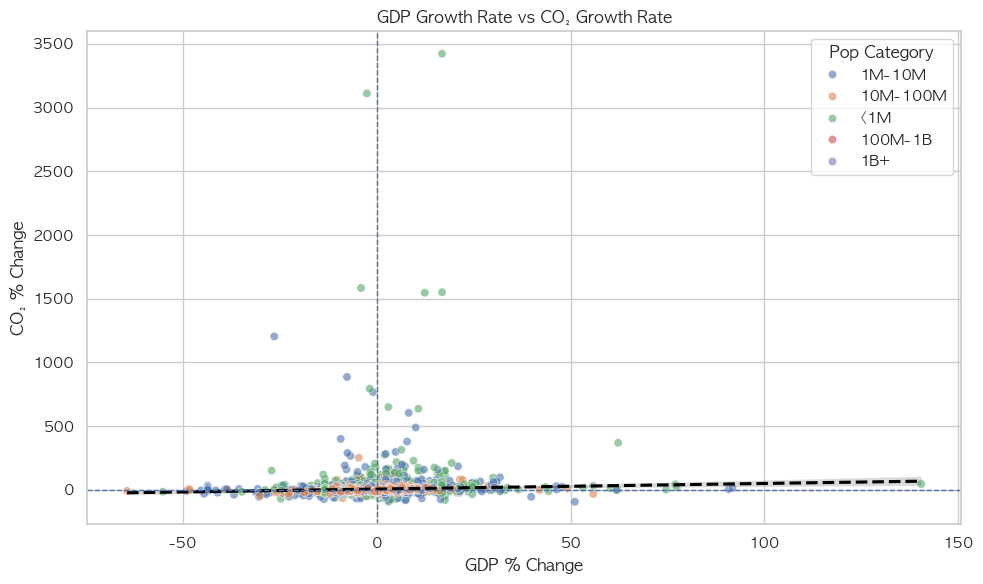

In [8]:
df_growth = (
    df_full_analysis[["GDP %", "CO2 %", "Pop Category"]]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .copy()
)

print("Growth-rate plot sample size:", df_growth.shape[0])

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_growth,
    x="GDP %",
    y="CO2 %",
    hue="Pop Category",
    alpha=0.6
)

sns.regplot(
    data=df_growth,
    x="GDP %",
    y="CO2 %",
    scatter=False,
    color="black",
    line_kws={"linestyle": "--"}
)

plt.title("GDP Growth Rate vs CO₂ Growth Rate")
plt.xlabel("GDP % Change")
plt.ylabel("CO₂ % Change")

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()

**해석**  
GDP 성장률과 CO₂ 배출량 성장률 사이에는 전반적으로 완만한 양의 관계가 나타난다.  
다만 일부 국가는 GDP가 증가하는 동시에 CO₂ 배출량이 감소하는 구간에 위치하며,  
이는 탈동조화 가능성을 보여주는 사례로 해석할 수 있다.

In [9]:
# 대표 국가 선정 근거 확인
check_countries = ["India", "Thailand", "Germany", "Sweden"]
correlations_df.loc[
    correlations_df["Country Name"].isin(check_countries),
    ["Country Name", "GDP_CO2_Correlation", "GDP_Per_Capita_CO2_Per_Capita_Correlation"]
]

,Country Name,GDP_CO2_Correlation,GDP_Per_Capita_CO2_Per_Capita_Correlation
70,Germany,-0.781486,-0.835858
84,India,0.996004,0.937255
174,Sweden,-0.787503,-0.830863
179,Thailand,0.991239,0.986215


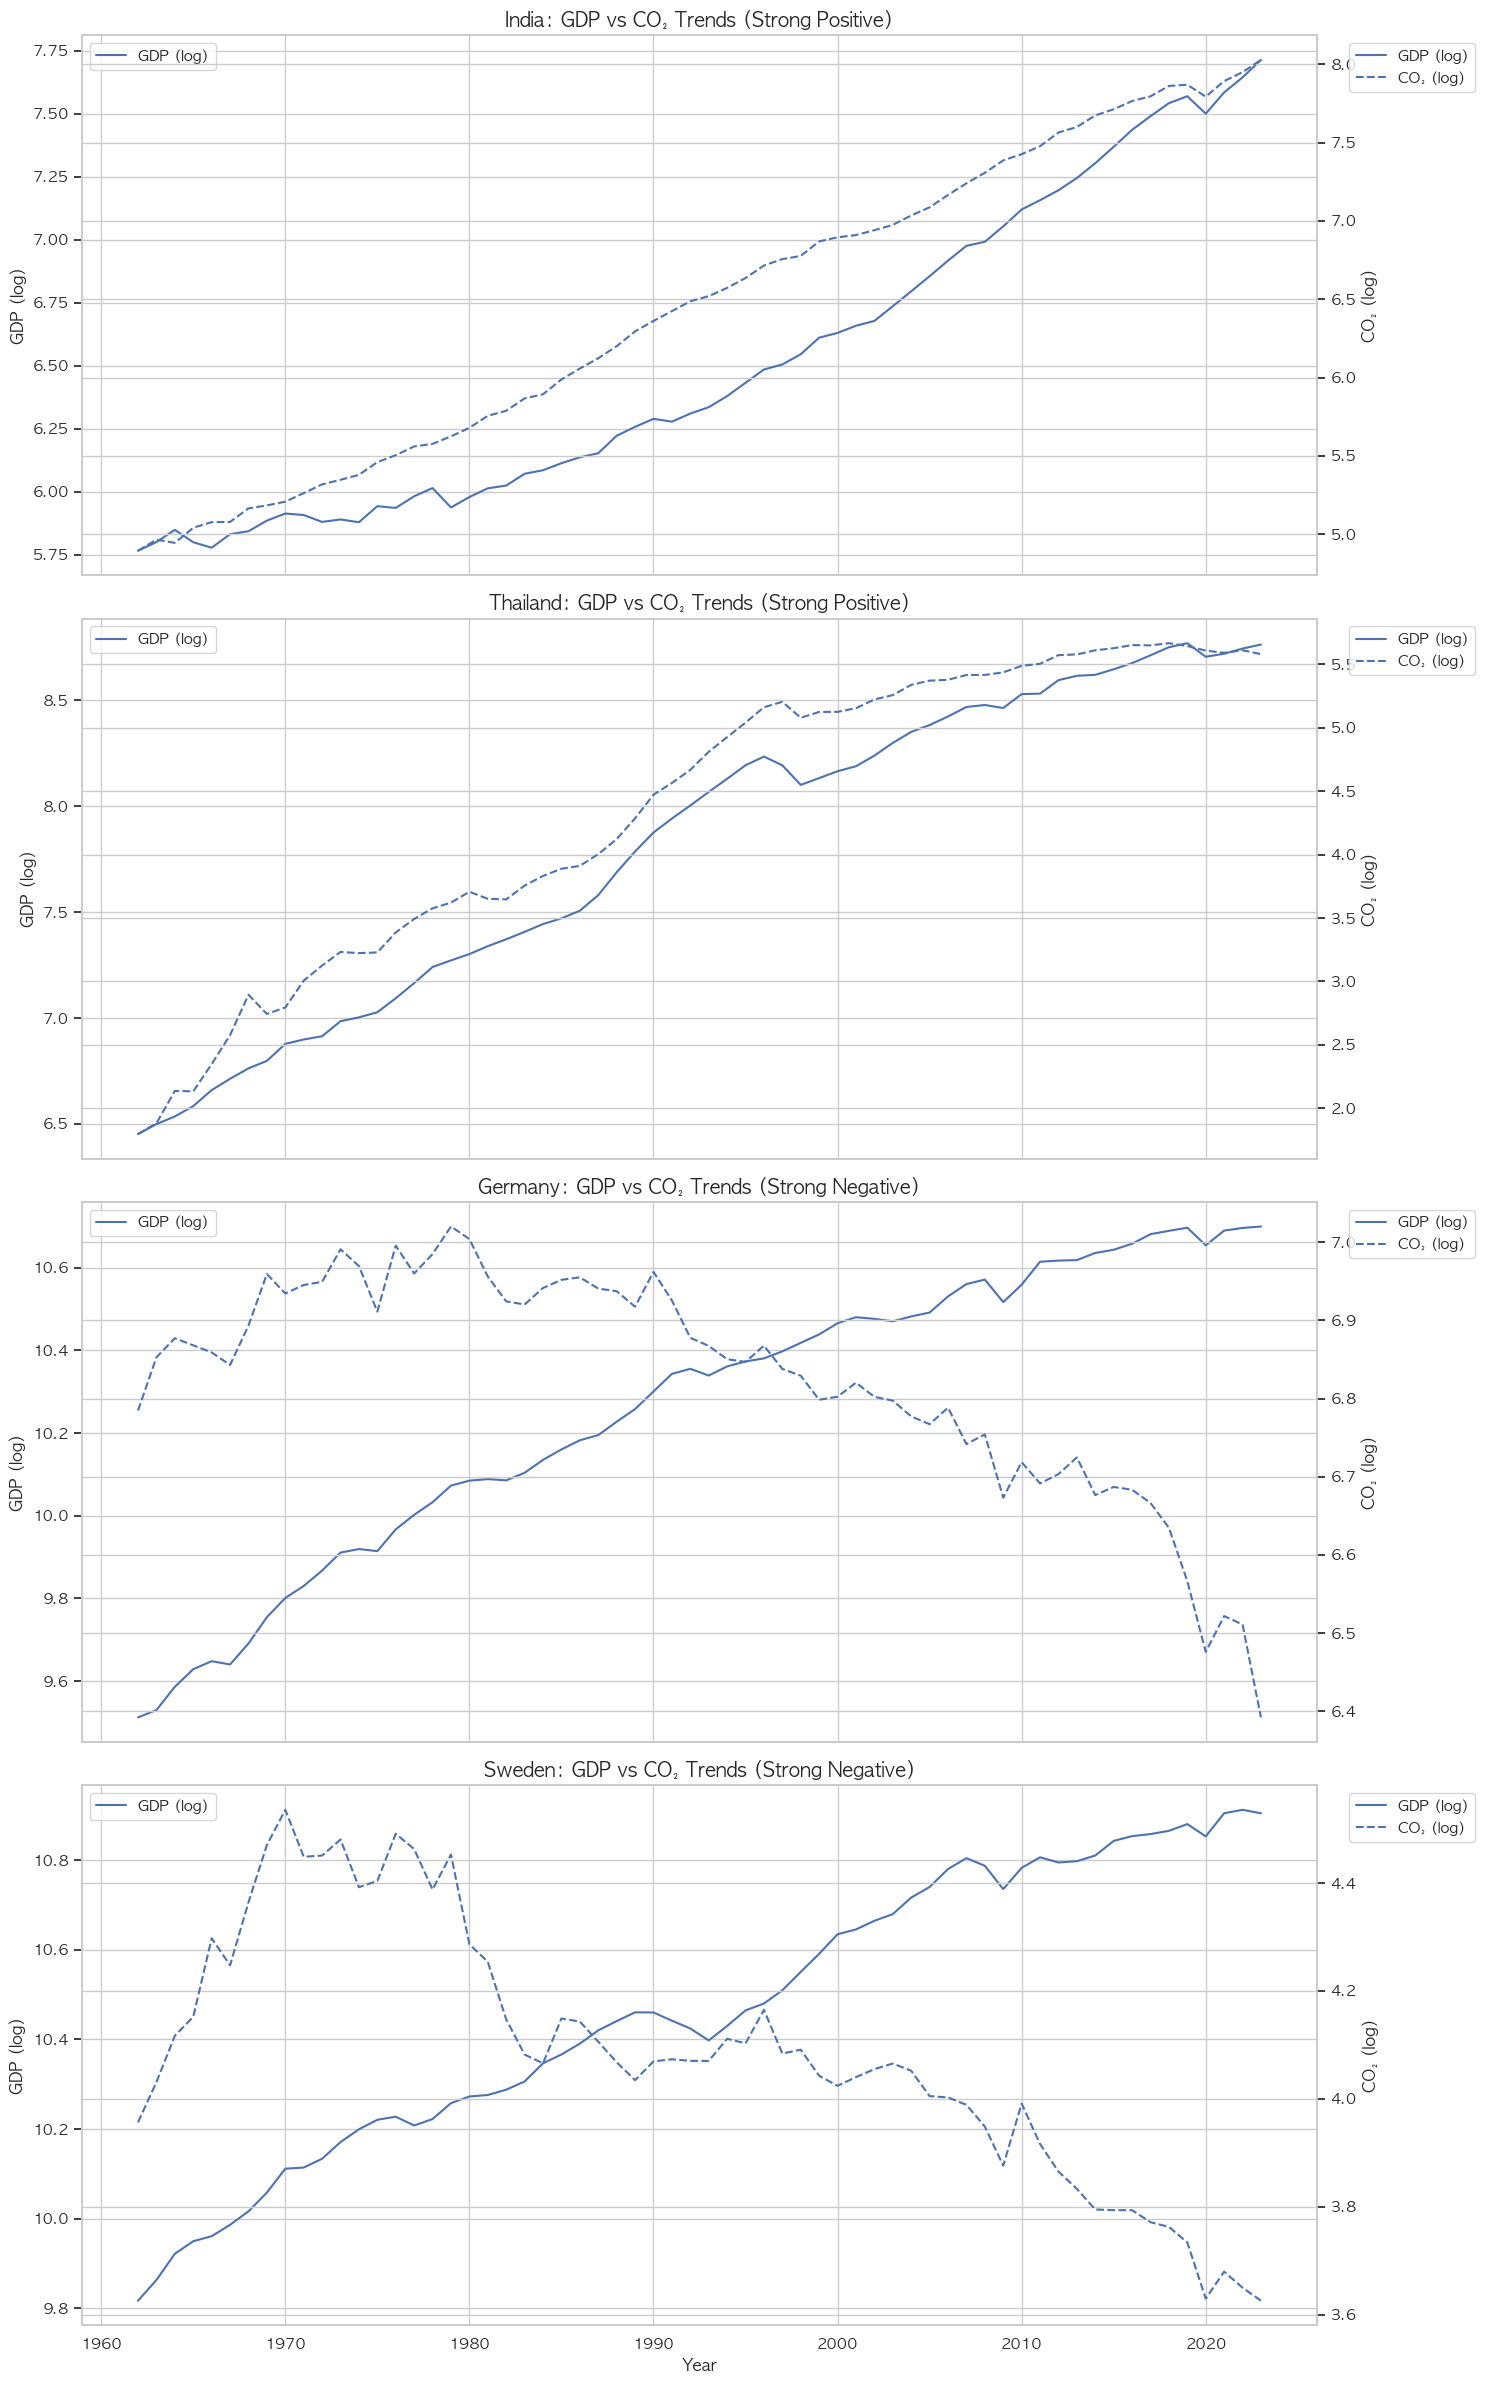

In [10]:
representative_countries = {
    "India": "Strong Positive",
    "Thailand": "Strong Positive",
    "Germany": "Strong Negative",
    "Sweden": "Strong Negative",
}

n = len(representative_countries)
fig, axes = plt.subplots(n, 1, figsize=(15, 6 * n), sharex=True)
axes = axes if n > 1 else [axes]

for ax, (country_name, correlation_type) in zip(axes, representative_countries.items()):
    country_data = (
        df_full_analysis[df_full_analysis["Country Name"] == country_name]
        .sort_values("Year")
        .dropna(subset=["GDP USD Log", "CO2 Log"])
    )

    if country_data.empty:
        ax.set_title(f"{country_name}: no data available")
        ax.axis("off")
        continue

    sns.lineplot(
        data=country_data,
        x="Year",
        y="GDP USD Log",
        ax=ax,
        label="GDP (log)"
    )
    ax.set_ylabel("GDP (log)")

    ax2 = ax.twinx()
    sns.lineplot(
        data=country_data,
        x="Year",
        y="CO2 Log",
        ax=ax2,
        label="CO₂ (log)",
        linestyle="--"
    )
    ax2.set_ylabel("CO₂ (log)")

    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc="upper left", bbox_to_anchor=(1.02, 1))

    ax.set_title(f"{country_name}: GDP vs CO₂ Trends ({correlation_type})", fontsize=14)
    ax.set_xlabel("Year")

plt.tight_layout()
plt.show()

**해석**  
강한 양(+)의 상관관계를 보이는 국가들은 GDP와 CO₂ 배출량이 함께 증가하는 추세를 보인다.  
반면, 음(–)의 상관관계를 보이는 국가들은 경제 성장이 지속되는 가운데 CO₂ 배출이 정체되거나 감소하는 양상을 나타내며,  
이는 성장과 배출 간 탈동조화 현상을 시사한다.

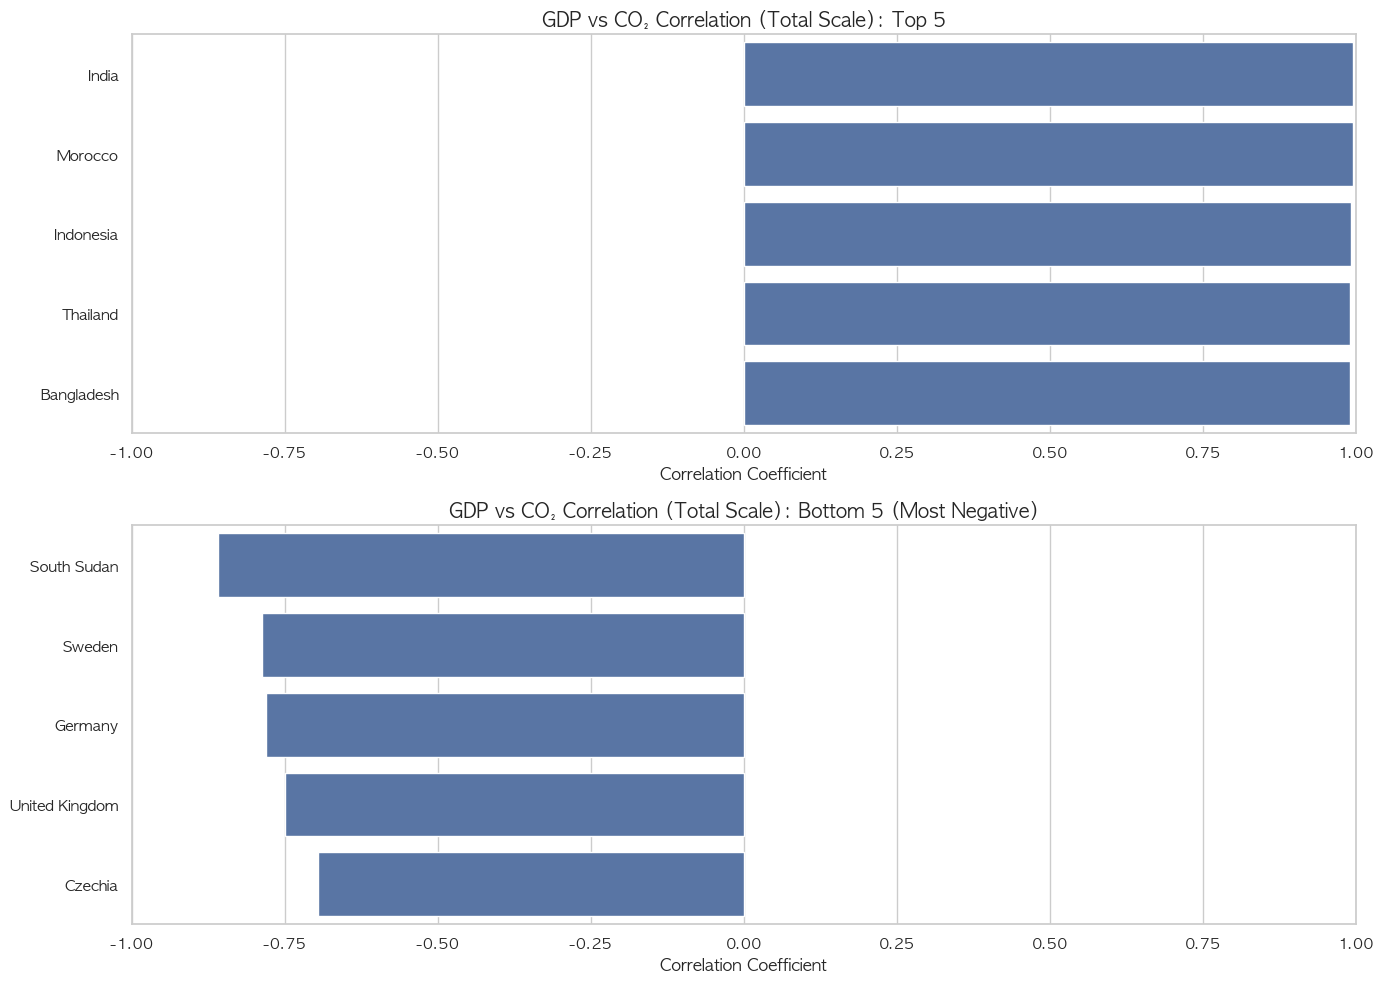

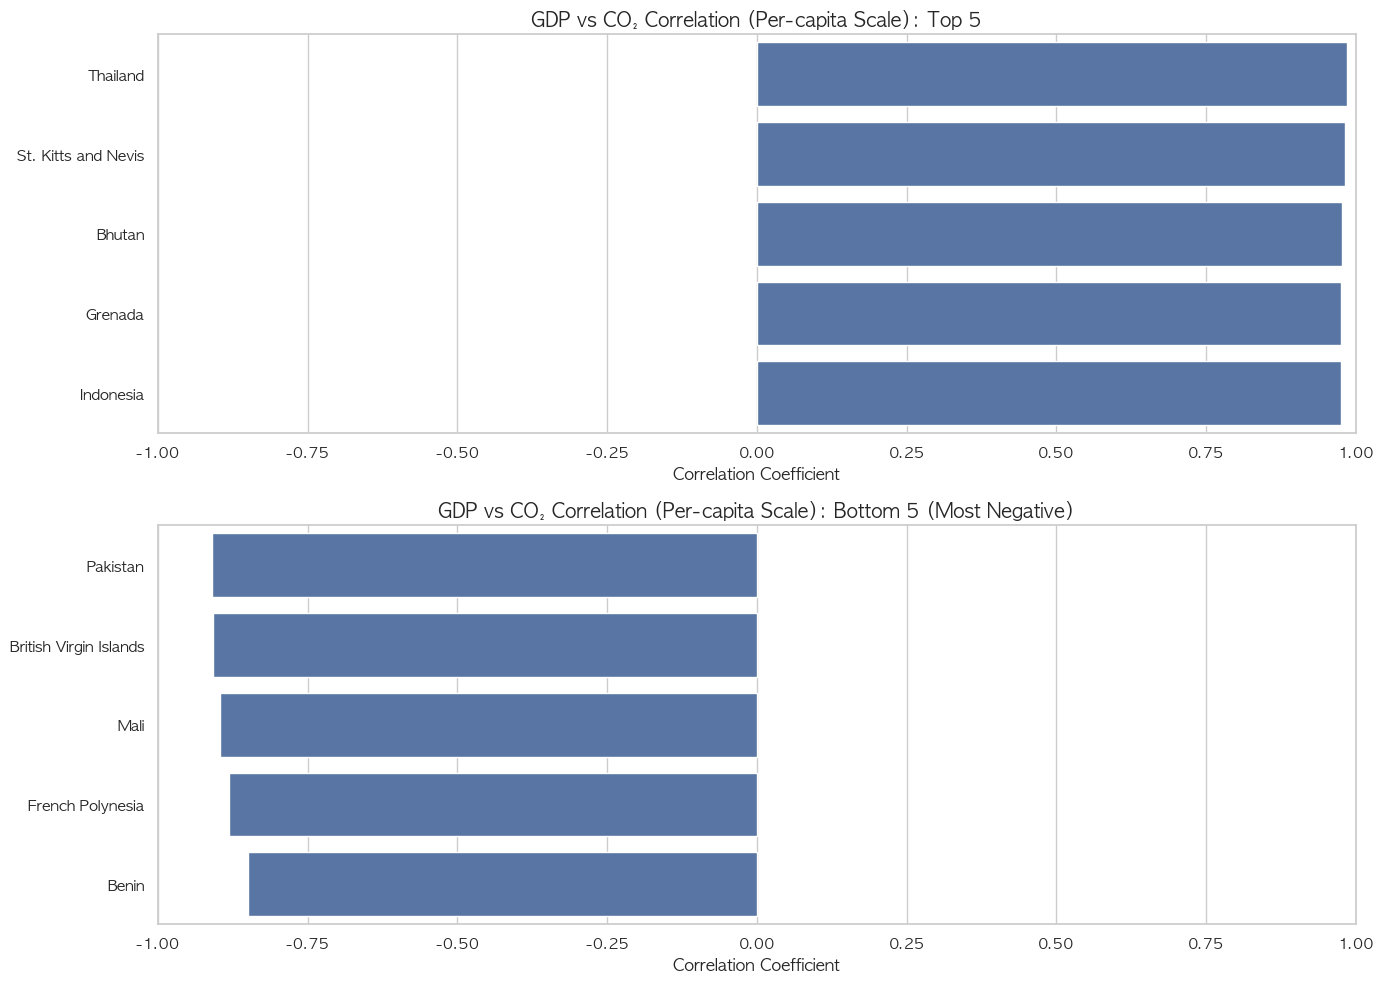

In [11]:
def plot_top_bottom(df, value_col, title_prefix, top_n=5):
    top = df.sort_values(value_col, ascending=False).head(top_n)
    bottom = df.sort_values(value_col, ascending=True).head(top_n)

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    sns.barplot(
        data=top,
        x=value_col,
        y="Country Name",
        ax=axes[0]
    )
    axes[0].set_title(f"{title_prefix}: Top {top_n}", fontsize=14)
    axes[0].set_xlabel("Correlation Coefficient")
    axes[0].set_ylabel("")
    axes[0].set_xlim(-1, 1)

    sns.barplot(
        data=bottom,
        x=value_col,
        y="Country Name",
        ax=axes[1]
    )
    axes[1].set_title(f"{title_prefix}: Bottom {top_n} (Most Negative)", fontsize=14)
    axes[1].set_xlabel("Correlation Coefficient")
    axes[1].set_ylabel("")
    axes[1].set_xlim(-1, 1)

    plt.tight_layout()
    plt.show()

plot_top_bottom(
    corr_plot_df,
    value_col="GDP_CO2_Correlation",
    title_prefix="GDP vs CO₂ Correlation (Total Scale)",
    top_n=5
)

plot_top_bottom(
    corr_plot_df,
    value_col="GDP_Per_Capita_CO2_Per_Capita_Correlation",
    title_prefix="GDP vs CO₂ Correlation (Per-capita Scale)",
    top_n=5
)

**해석**  
상관계수 상·하위 국가는 성장–배출 관계가 극단적으로 나타나는 사례로,  
동조화(강한 양의 상관) 및 탈동조화(음의 상관)의 대표 패턴을 보여준다.  
다만 상관계수는 관측 기간과 변동성의 영향을 받을 수 있으므로, 국가별 시계열 추이와 함께 해석할 필요가 있다.

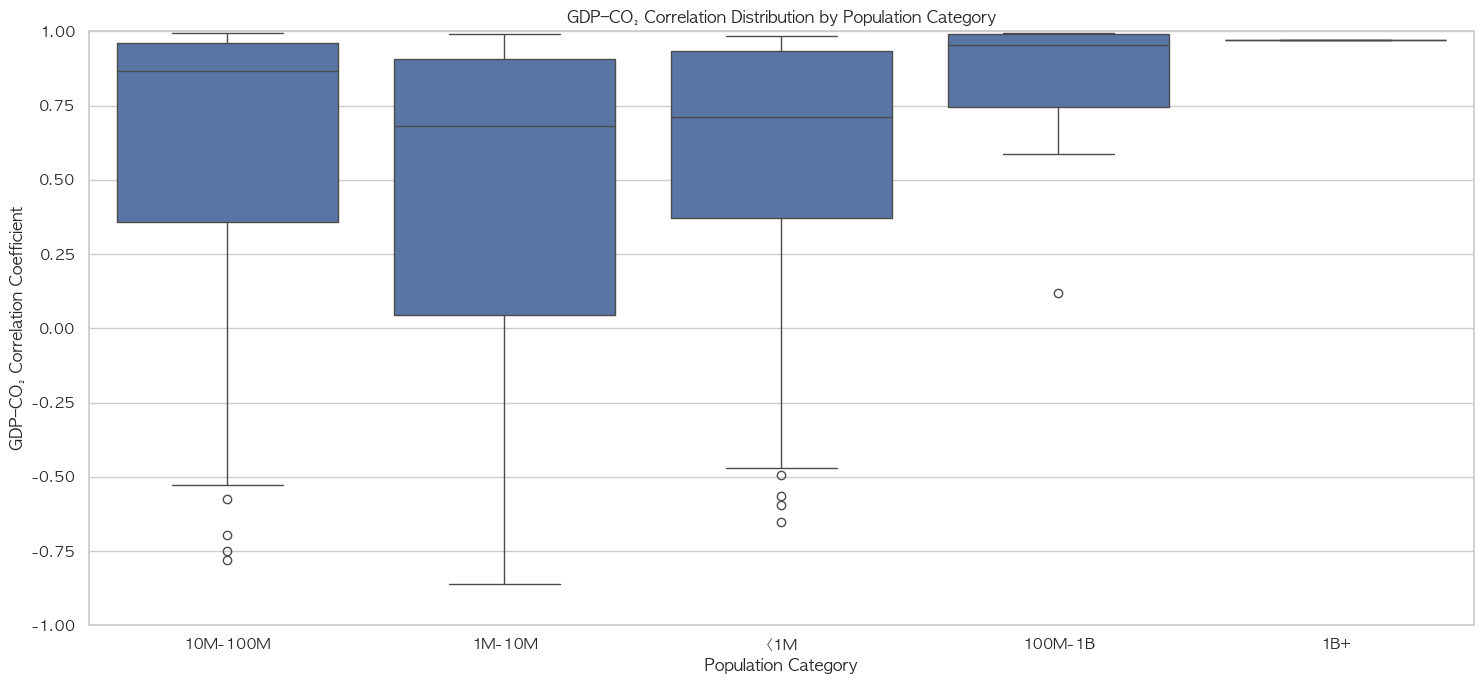

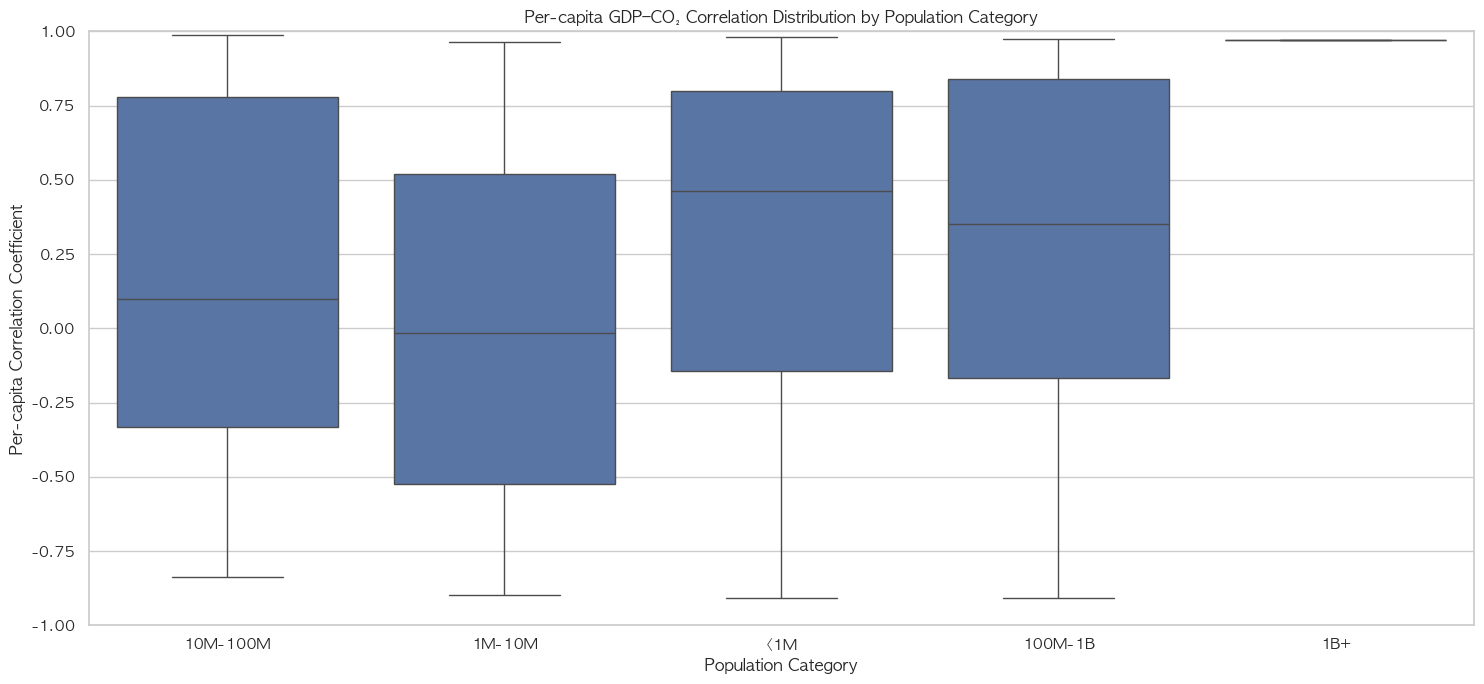

In [12]:
plt.figure(figsize=(15, 7))
sns.boxplot(
    data=corr_plot_df,
    x="Pop Category",
    y="GDP_CO2_Correlation"
)
plt.title("GDP–CO₂ Correlation Distribution by Population Category")
plt.xlabel("Population Category")
plt.ylabel("GDP–CO₂ Correlation Coefficient")
plt.ylim(-1, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 7))
sns.boxplot(
    data=corr_plot_df,
    x="Pop Category",
    y="GDP_Per_Capita_CO2_Per_Capita_Correlation"
)
plt.title("Per-capita GDP–CO₂ Correlation Distribution by Population Category")
plt.xlabel("Population Category")
plt.ylabel("Per-capita Correlation Coefficient")
plt.ylim(-1, 1)
plt.tight_layout()
plt.show()

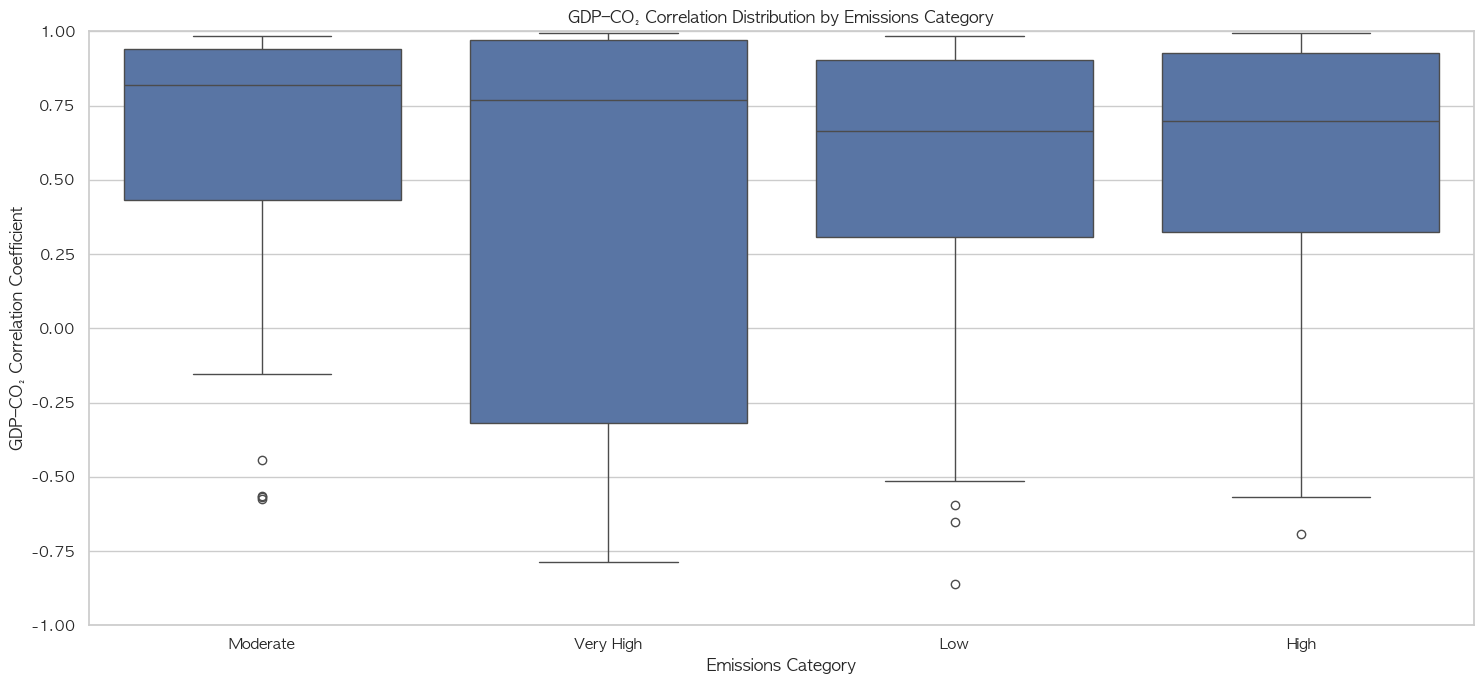

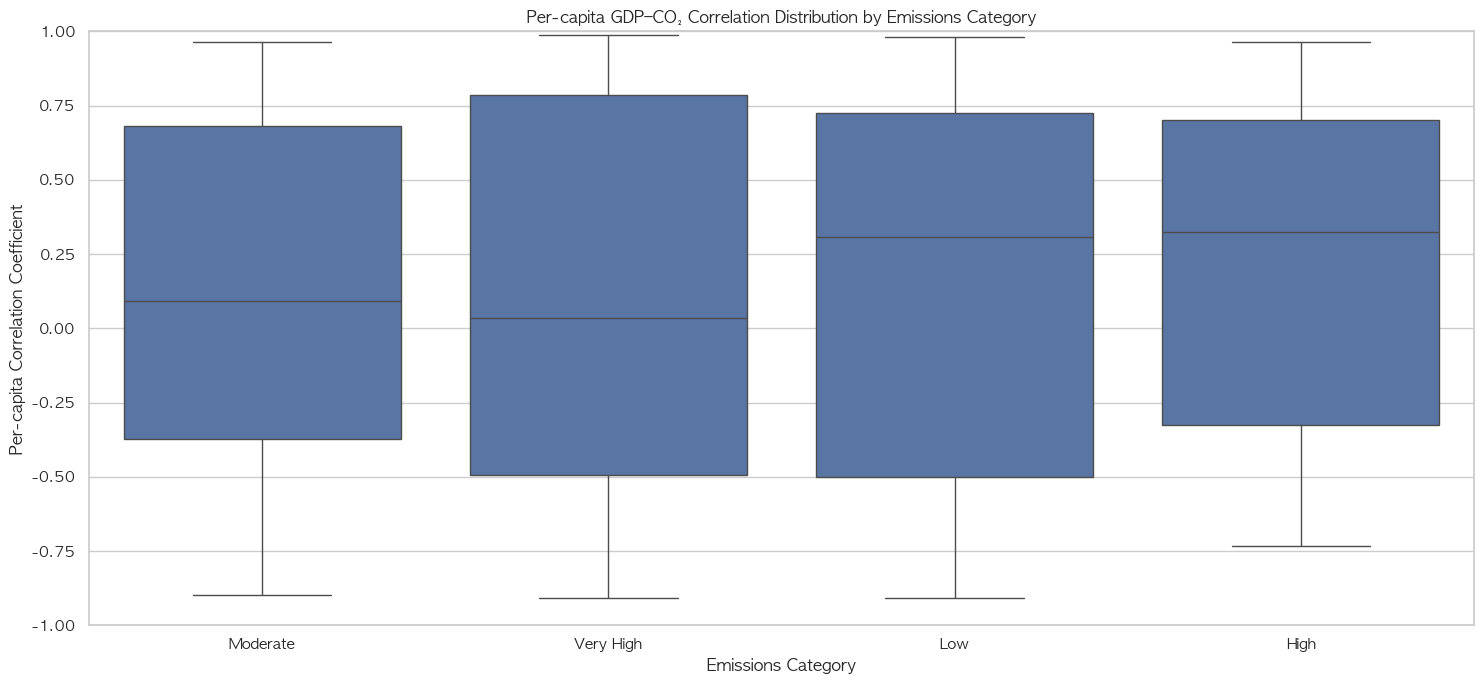

In [13]:
plt.figure(figsize=(15, 7))
sns.boxplot(
    data=corr_plot_df,
    x="Emissions Category",
    y="GDP_CO2_Correlation"
)
plt.title("GDP–CO₂ Correlation Distribution by Emissions Category")
plt.xlabel("Emissions Category")
plt.ylabel("GDP–CO₂ Correlation Coefficient")
plt.ylim(-1, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 7))
sns.boxplot(
    data=corr_plot_df,
    x="Emissions Category",
    y="GDP_Per_Capita_CO2_Per_Capita_Correlation"
)
plt.title("Per-capita GDP–CO₂ Correlation Distribution by Emissions Category")
plt.xlabel("Emissions Category")
plt.ylabel("Per-capita Correlation Coefficient")
plt.ylim(-1, 1)
plt.tight_layout()
plt.show()

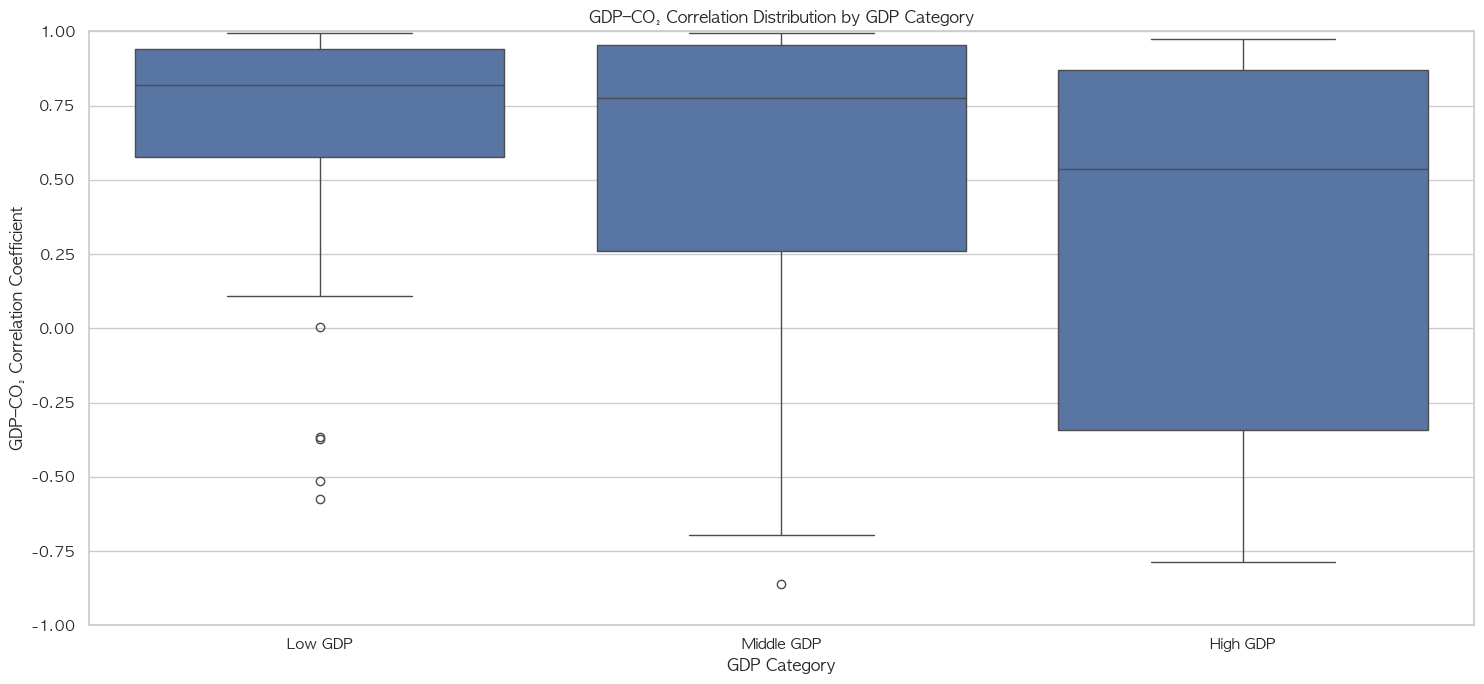

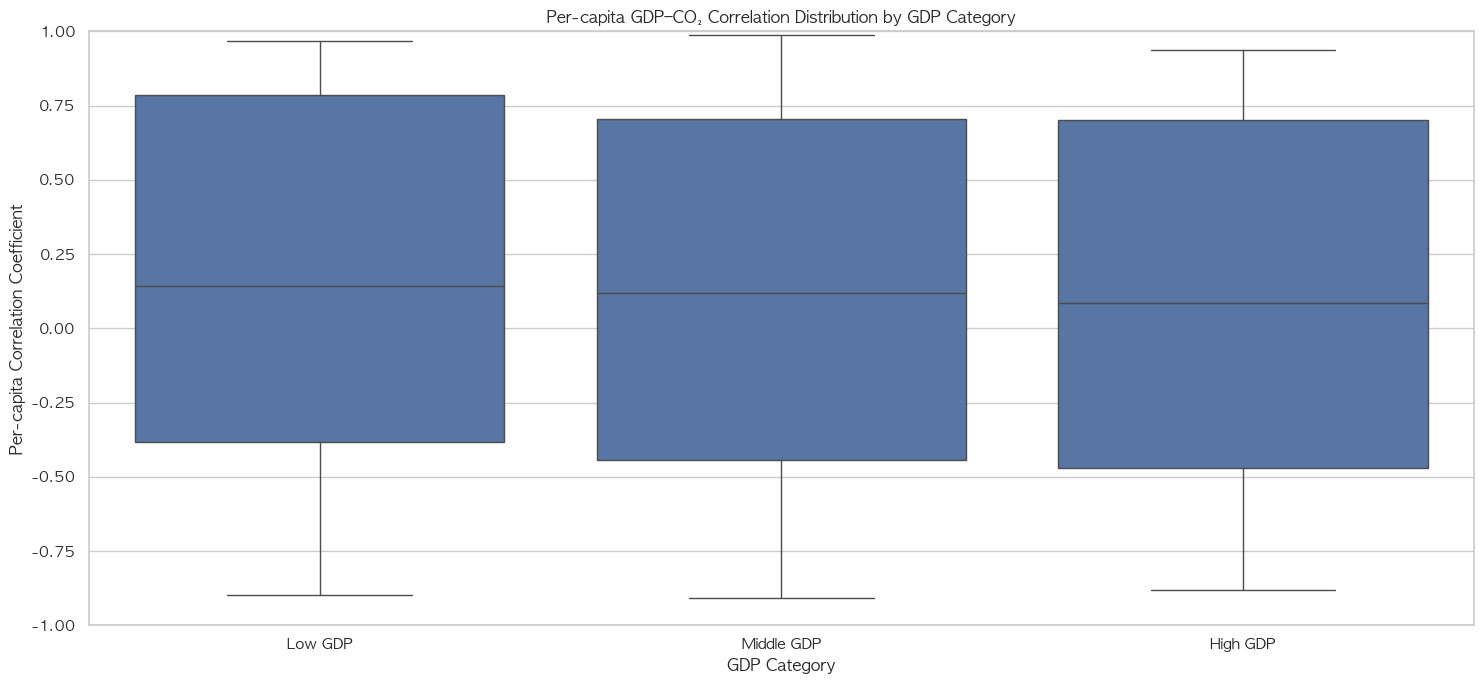

In [14]:
plt.figure(figsize=(15, 7))
sns.boxplot(
    data=corr_plot_df,
    x="GDP Category",
    y="GDP_CO2_Correlation"
)
plt.title("GDP–CO₂ Correlation Distribution by GDP Category")
plt.xlabel("GDP Category")
plt.ylabel("GDP–CO₂ Correlation Coefficient")
plt.ylim(-1, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 7))
sns.boxplot(
    data=corr_plot_df,
    x="GDP Category",
    y="GDP_Per_Capita_CO2_Per_Capita_Correlation"
)
plt.title("Per-capita GDP–CO₂ Correlation Distribution by GDP Category")
plt.xlabel("GDP Category")
plt.ylabel("Per-capita Correlation Coefficient")
plt.ylim(-1, 1)
plt.tight_layout()
plt.show()

**해석**  
국가의 인구 규모, 배출 수준, 경제 발전 단계에 따라 GDP–CO₂ 상관관계 분포는 서로 다르게 나타난다.  
특히 GDP 수준이 높은 국가에서는 총량 및 1인당 기준 모두에서 음의 상관관계가 나타나는 사례가 증가하며,  
이는 경제 발전 단계에 따라 성장–배출 관계가 구조적으로 변화할 수 있음을 시사한다.

## Conclusion

본 분석에서는 국가별 GDP와 CO₂ 배출량 간의 관계를 시각화 중심으로 탐색하였다.  
분석 결과, 다수의 국가에서는 경제 성장과 CO₂ 배출 증가가 함께 나타나는 동조화 현상이 여전히 우세하였다.

반면 일부 고소득 국가에서는 GDP가 성장하는 가운데 CO₂ 배출량이 감소하거나 안정화되는 탈동조화 양상이 확인되었다.  
또한 총량 기준과 1인당 기준의 결과가 다르게 나타나는 경우도 존재하여,  
성장–배출 관계는 국가의 인구 규모, 경제 수준, 배출 구조 등에 따라 복합적으로 달라질 수 있음을 확인하였다.

이러한 결과는 경제 성장과 환경 부담 간 관계를 단순한 총량 비교로만 해석하기보다,  
국가의 구조적 특성과 지표의 관점을 함께 고려해야 함을 보여준다.